# AcousTools — Getting Started Guide

## What is this notebook?

This notebook is a **hands-on introduction** to [AcousTools](https://github.com/JoshuaMukherjee/AcousTools), a Python library for simulating **acoustic holography** and **ultrasonic levitation**. By running through each cell, you will learn how an array of ultrasound transducers can be controlled to create invisible "traps" in mid-air using focused sound waves.

---

## What does this notebook simulate?

### The physical setup
Imagine two flat boards, each containing a **16×16 grid of tiny ultrasound speakers** (transducers), facing each other. These transducers all emit at **40 kHz** (far above human hearing). By carefully controlling the **phase** (timing) of each transducer, we can make all waves arrive "in sync" at a chosen point in space — creating a region of very high acoustic pressure called a **focal point**.

```
    ┌─────────────────┐  ← Top board (256 transducers)
    │ ○ ○ ○ ○ ○ ○ ○ ○ │
    │ ○ ○ ○ ○ ○ ○ ○ ○ │     Sound waves travel
    │ ○ ○ ○ ○ ○ ○ ○ ○ │     downward ↓ & upward ↑
    └─────────────────┘
              ↕  working volume (where trapping happens)
    ┌─────────────────┐
    │ ○ ○ ○ ○ ○ ○ ○ ○ │  ← Bottom board (256 transducers)
    │ ○ ○ ○ ○ ○ ○ ○ ○ │
    │ ○ ○ ○ ○ ○ ○ ○ ○ │     Total: 512 transducers
    └─────────────────┘
```

### What each section does

| Section | What it does | What you learn |
|---|---|---|
| **1. Verify Installation** | Imports PyTorch and AcousTools | Confirm your environment is set up |
| **2. Transducer Board** | Loads the default 512-transducer layout | How the physical hardware is represented as a tensor |
| **3. Creating Points** | Defines target locations in 3D space | The `(B, 3, N)` tensor convention for points |
| **4. Solving for Activations** | Runs the **WGS** (Weighted Gerchberg-Saxton) algorithm | How the solver computes what phase each transducer needs |
| **5. Propagation** | Calculates the acoustic pressure at target points | How wave superposition creates a focused field |
| **6. Field Visualisation (XZ plane)** | Plots 2D maps of pressure amplitude, intensity, and phase | See the acoustic field "from the side" — the focal spot and interference patterns |
| **7. Field Visualisation (XY plane + line profiles)** | Top-down view + 1D cross-section plots | See how sharply the focus peaks and falls off |
| **8. Multi-Point Focusing** | Focuses on 3 points simultaneously | How acoustic levitation of multiple particles works |
| **9. Gorkov Potential** | Computes trapping strength at the focus | Whether a small particle would be stably trapped |
| **10. Physical Constants** | Lists the simulation parameters | Speed of sound, frequency, wavelength, etc. |
| **11. Next Steps** | Suggested learning paths | Where to go from here |

### Key physics concepts in the simulation

- **Acoustic holography**: Computing the transducer phases needed to produce a desired pressure pattern — analogous to optical holography but with sound.
- **Constructive interference**: When waves from all 512 transducers arrive in phase at the target, their pressures add up to create a sharp peak.
- **Pressure amplitude |p|**: The strength of the sound wave at each point (measured in Pascals). Higher = louder.
- **Sound intensity ∝ |p|²**: The energy flux of the wave. Proportional to the square of pressure — so the focus is even more prominent on intensity plots.
- **Phase**: The "timing offset" of the wave at each point. The solver manipulates transducer phases so waves constructively interfere at the targets.
- **Gorkov potential**: A scalar field that tells you where a small particle would be pushed. Particles are attracted to minima of the Gorkov potential — these are the "traps".

---

## Resources

| Resource | Link |
|---|---|
| **API Documentation** | https://joshuamukherjee.github.io/AcousTools/src/acoustools.html |
| **Code Examples** | https://github.com/JoshuaMukherjee/AcousticExperiments/tree/main/AcousTools_Examples |
| **arXiv Paper** | https://arxiv.org/abs/2511.07336 |

---

## Module Overview

| Module | Purpose |
|---|---|
| `acoustools.Utilities` | Create points, transducer boards, propagation helpers |
| `acoustools.Solvers` | Compute transducer activations (WGS, GSPAT, Naive, Gradient, etc.) |
| `acoustools.Gorkov` | Compute Gorkov potential (trapping force analysis) |
| `acoustools.Force` | Compute acoustic radiation forces |
| `acoustools.Visualiser` | Visualise pressure fields as 2D slices |
| `acoustools.BEM` | Boundary Element Method for scattering off objects |
| `acoustools.Mesh` | Load and manipulate 3D meshes |
| `acoustools.Levitator` | Interface with physical levitator hardware |
| `acoustools.Constants` | Physical constants (speed of sound, frequency, etc.) |
| `acoustools.Paths` | Create paths / interpolations for moving particles |
| `acoustools.Optimise` | Optimisation routines for acoustic setups |

## 1. Verify Installation

In [34]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")

import acoustools
print("AcousTools imported successfully!")

PyTorch version: 2.10.0+cpu
CUDA available:  False
AcousTools imported successfully!


## 2. Understanding the Transducer Board

AcousTools models a transducer array — a grid of small ultrasound emitters.  
The default setup is two opposing 16×16 boards (top and bottom), typical of acoustic levitation rigs.

In [35]:
from acoustools.Utilities import TRANSDUCERS, create_points, propagate

# TRANSDUCERS is the default board layout
print(f"Number of transducers: {TRANSDUCERS.shape[0]}")
print(f"Transducer positions shape: {TRANSDUCERS.shape}")
print(f"\nFirst 5 transducer positions (x, y, z) in metres:")
print(TRANSDUCERS[:5])

Number of transducers: 512
Transducer positions shape: torch.Size([512, 3])

First 5 transducer positions (x, y, z) in metres:
tensor([[-0.0787, -0.0787,  0.1182],
        [-0.0787, -0.0683,  0.1182],
        [-0.0787, -0.0577,  0.1182],
        [-0.0787, -0.0472,  0.1182],
        [-0.0787, -0.0367,  0.1182]])


## 3. Creating Target Points

Points in AcousTools are `(B, 3, N)` tensors:  
- **B** = batch size (for parallel computation)  
- **3** = x, y, z coordinates  
- **N** = number of points  

`create_points` makes random points in the working volume.

In [36]:
# Create a single point at the origin
single_point = torch.zeros(1, 3, 1)  # B=1, 3D, N=1
print(f"Single point at origin: {single_point.squeeze()}")

# Create N random points using the utility
N = 4
random_points = create_points(N, B=1)  # 4 random points, 1 batch
print(f"\nRandom points shape: {random_points.shape}")
print(f"Random points:\n{random_points.squeeze(0).T}")

Single point at origin: tensor([0., 0., 0.])

Random points shape: torch.Size([1, 3, 4])
Random points:
tensor([[-0.0336+0.j, -0.0034+0.j, -0.0144+0.j],
        [-0.0322+0.j,  0.0255+0.j,  0.0585+0.j],
        [ 0.0139+0.j,  0.0081+0.j, -0.0164+0.j],
        [-0.0229+0.j,  0.0328+0.j, -0.0354+0.j]])


## 4. Solving for Transducer Activations

A **solver** computes the complex activations (amplitude + phase) for each transducer  
so that the acoustic field focuses at the desired target points.

Common solvers:
- **`wgs`** — Weighted Gerchberg-Saxton (iterative, good quality)
- **`gspat`** — GS-PAT (fast, GPU-friendly)
- **`naive`** — Simple phase-matching (baseline)

In [37]:
from acoustools.Solvers import wgs

# Create a single target point at the origin
point = torch.zeros(1, 3, 1)

# Solve for transducer activations using Weighted Gerchberg-Saxton
activations = wgs(point)

print(f"Activations shape: {activations.shape}")
print(f"Activations are complex: {activations.is_complex()}")
print(f"\nPhases (first 10 transducers) in radians:")
print(torch.angle(activations[0, :10, 0]))

Activations shape: torch.Size([1, 512, 1])
Activations are complex: True

Phases (first 10 transducers) in radians:
tensor([ 0.1574, -2.5921,  0.5252, -3.0926, -0.9127,  0.7517,  1.8759,  2.4426,
         2.4426,  1.8759])


## 5. Propagating the Acoustic Field

`propagate` computes the complex pressure at any set of evaluation points,  
given the transducer activations.

In [38]:
# Compute the pressure at the target point
pressure = propagate(activations, point)

print(f"Complex pressure at target: {pressure.item():.4f}")
print(f"Pressure amplitude (Pa):    {pressure.abs().item():.4f}")
print(f"Phase (radians):            {torch.angle(pressure).item():.4f}")

Complex pressure at target: 9273.7695-1872.3562j
Pressure amplitude (Pa):    9460.8945
Phase (radians):            -0.1992


## 6. Visualising the Pressure Field

The `Visualiser` module lets you see 2D slices of the acoustic pressure field.  
This is essential for understanding what the transducers are actually producing.

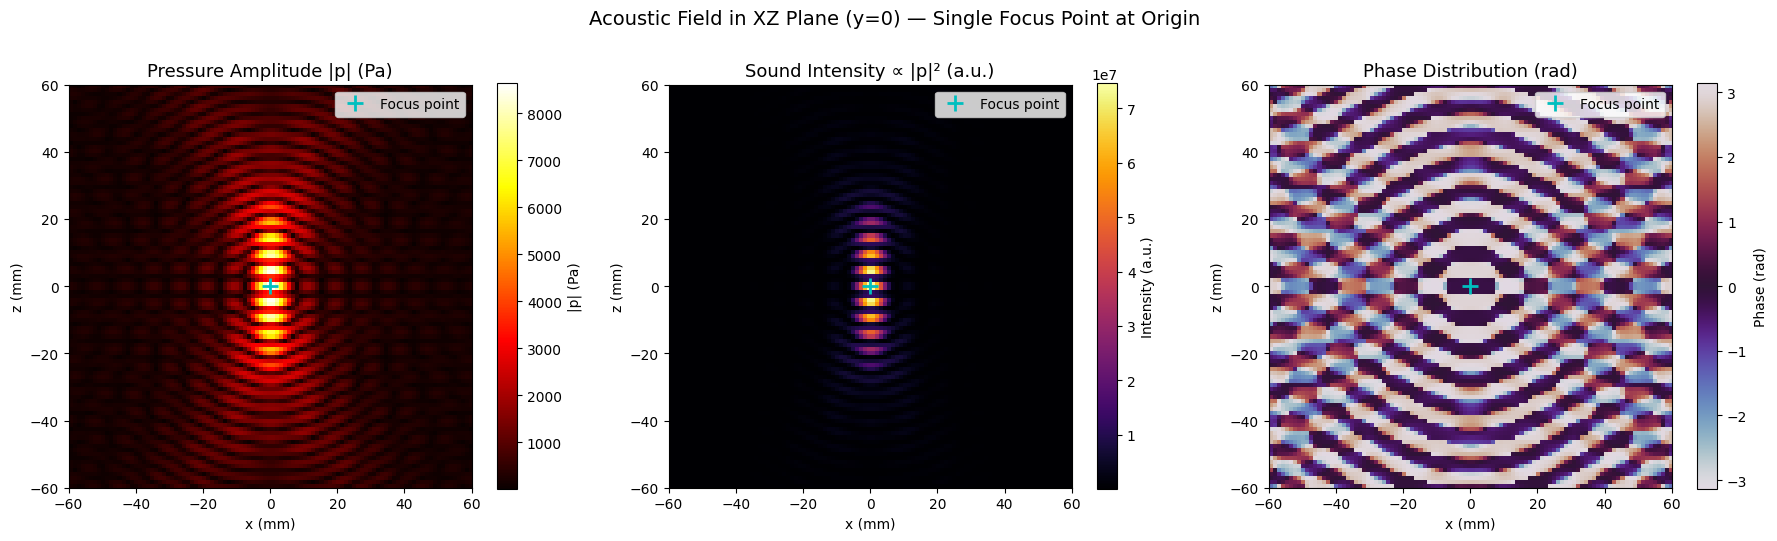

In [39]:
from acoustools.Visualiser import Visualise
from acoustools.Utilities import create_points, propagate, add_lev_sig
import matplotlib.pyplot as plt
import numpy as np

# Define a single focus point at the origin
point = torch.zeros(1, 3, 1)

# Solve for activations
activations = wgs(point)

# --- Create a grid of evaluation points in the XZ plane (y=0) ---
res = 100  # grid resolution
x_range = torch.linspace(-0.06, 0.06, res)
z_range = torch.linspace(-0.06, 0.06, res)
xx, zz = torch.meshgrid(x_range, z_range, indexing='ij')

# Build evaluation points: shape (1, 3, res*res)
eval_points = torch.stack([
    xx.flatten(),
    torch.zeros(res * res),   # y = 0
    zz.flatten()
], dim=0).unsqueeze(0)  # (1, 3, N)

# Propagate to get complex pressure at every grid point
pressure_field = propagate(activations, eval_points)  # (1, N)

# Reshape to 2D grid — use [0] to take batch dim explicitly (safer than .squeeze())
pressure_2d = pressure_field[0].reshape(res, res)

# --- Plot 1: Pressure Amplitude ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

p_amp = pressure_2d.abs().numpy()
im0 = axes[0].imshow(p_amp.T, extent=[-60, 60, -60, 60], origin='lower', cmap='hot', aspect='equal')
axes[0].set_title('Pressure Amplitude |p| (Pa)', fontsize=13)
axes[0].set_xlabel('x (mm)')
axes[0].set_ylabel('z (mm)')
fig.colorbar(im0, ax=axes[0], label='|p| (Pa)')
axes[0].plot(0, 0, 'c+', markersize=12, markeredgewidth=2, label='Focus point')
axes[0].legend()

# --- Plot 2: Sound Intensity (proportional to |p|^2) ---
# Intensity I ∝ |p|^2 / (ρ * c)  — we plot relative intensity
intensity = (p_amp ** 2)
im1 = axes[1].imshow(intensity.T, extent=[-60, 60, -60, 60], origin='lower', cmap='inferno', aspect='equal')
axes[1].set_title('Sound Intensity ∝ |p|² (a.u.)', fontsize=13)
axes[1].set_xlabel('x (mm)')
axes[1].set_ylabel('z (mm)')
fig.colorbar(im1, ax=axes[1], label='Intensity (a.u.)')
axes[1].plot(0, 0, 'c+', markersize=12, markeredgewidth=2, label='Focus point')
axes[1].legend()

# --- Plot 3: Phase Distribution ---
phase = torch.angle(pressure_2d).numpy()
im2 = axes[2].imshow(phase.T, extent=[-60, 60, -60, 60], origin='lower', cmap='twilight', aspect='equal')
axes[2].set_title('Phase Distribution (rad)', fontsize=13)
axes[2].set_xlabel('x (mm)')
axes[2].set_ylabel('z (mm)')
fig.colorbar(im2, ax=axes[2], label='Phase (rad)')
axes[2].plot(0, 0, 'c+', markersize=12, markeredgewidth=2, label='Focus point')
axes[2].legend()

plt.suptitle('Acoustic Field in XZ Plane (y=0) — Single Focus Point at Origin', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### XY Plane View & Line Profiles

Let's also look at the field from above (XY plane at z=0) and plot 1D line profiles of pressure and intensity through the focus.

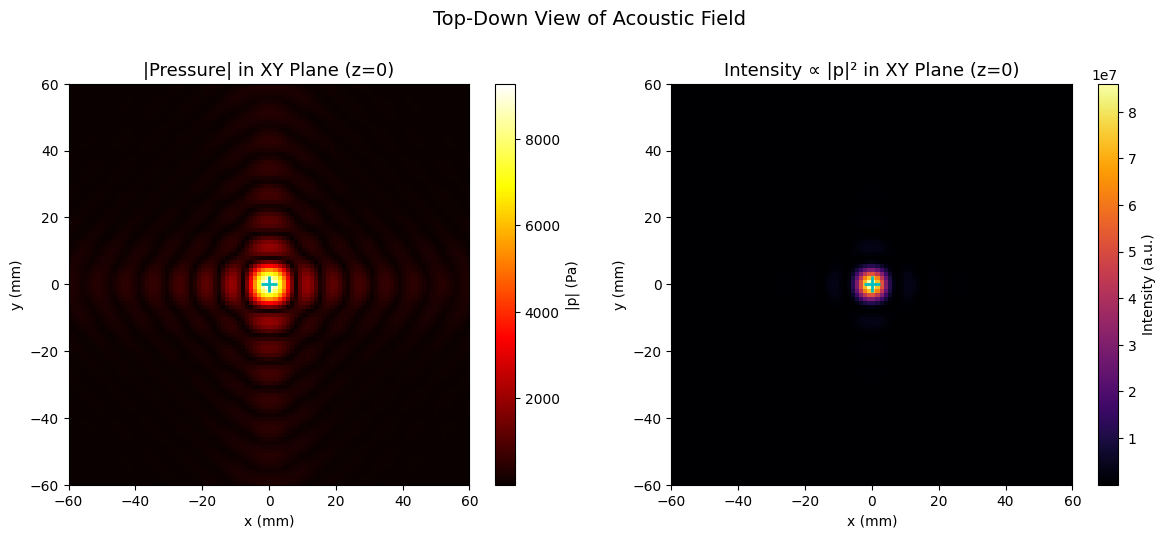

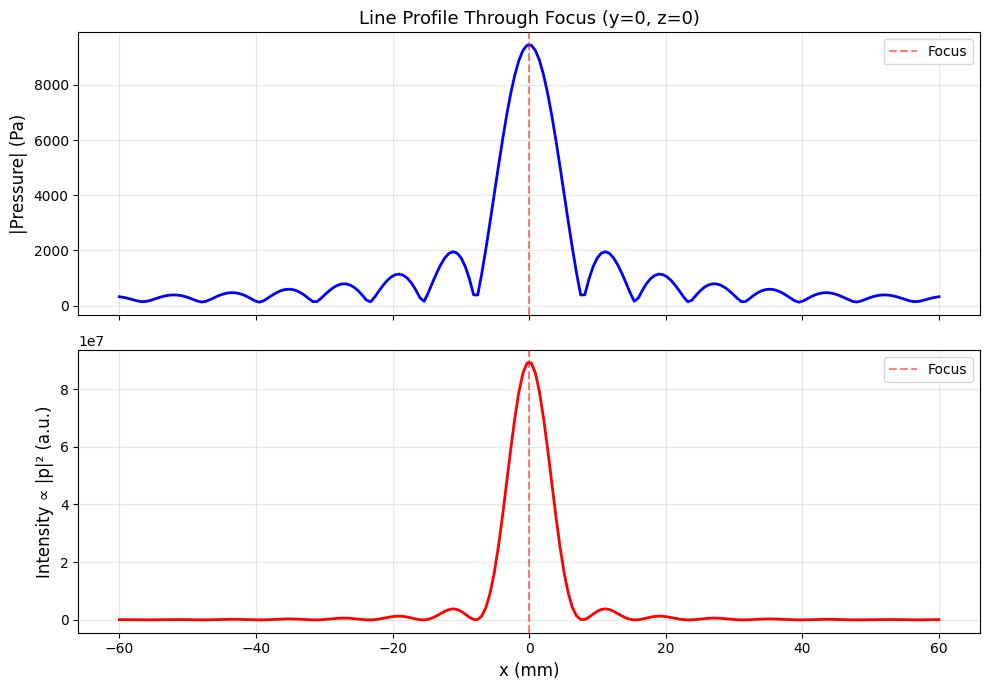

In [40]:
# --- XY Plane (z=0) ---
res = 100
x_range = torch.linspace(-0.06, 0.06, res)
y_range = torch.linspace(-0.06, 0.06, res)
xx, yy = torch.meshgrid(x_range, y_range, indexing='ij')

eval_xy = torch.stack([
    xx.flatten(),
    yy.flatten(),
    torch.zeros(res * res)   # z = 0
], dim=0).unsqueeze(0)

p_xy = propagate(activations, eval_xy)[0].reshape(res, res)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pressure amplitude - XY plane
im0 = axes[0].imshow(p_xy.abs().numpy().T, extent=[-60, 60, -60, 60],
                      origin='lower', cmap='hot', aspect='equal')
axes[0].set_title('|Pressure| in XY Plane (z=0)', fontsize=13)
axes[0].set_xlabel('x (mm)')
axes[0].set_ylabel('y (mm)')
fig.colorbar(im0, ax=axes[0], label='|p| (Pa)')
axes[0].plot(0, 0, 'c+', markersize=12, markeredgewidth=2)

# Intensity - XY plane
im1 = axes[1].imshow((p_xy.abs().numpy().T)**2, extent=[-60, 60, -60, 60],
                      origin='lower', cmap='inferno', aspect='equal')
axes[1].set_title('Intensity ∝ |p|² in XY Plane (z=0)', fontsize=13)
axes[1].set_xlabel('x (mm)')
axes[1].set_ylabel('y (mm)')
fig.colorbar(im1, ax=axes[1], label='Intensity (a.u.)')
axes[1].plot(0, 0, 'c+', markersize=12, markeredgewidth=2)

plt.suptitle('Top-Down View of Acoustic Field', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- 1D Line Profiles along x-axis (y=0, z=0) ---
x_line = torch.linspace(-0.06, 0.06, 200)
line_points = torch.stack([
    x_line,
    torch.zeros(200),
    torch.zeros(200)
], dim=0).unsqueeze(0)

p_line = propagate(activations, line_points).squeeze()
x_mm = x_line.numpy() * 1000  # convert to mm

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Pressure amplitude line profile
ax1.plot(x_mm, p_line.abs().numpy(), 'b-', linewidth=2)
ax1.axvline(0, color='red', linestyle='--', alpha=0.5, label='Focus')
ax1.set_ylabel('|Pressure| (Pa)', fontsize=12)
ax1.set_title('Line Profile Through Focus (y=0, z=0)', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Intensity line profile
ax2.plot(x_mm, (p_line.abs().numpy())**2, 'r-', linewidth=2)
ax2.axvline(0, color='red', linestyle='--', alpha=0.5, label='Focus')
ax2.set_xlabel('x (mm)', fontsize=12)
ax2.set_ylabel('Intensity ∝ |p|² (a.u.)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Multi-Point Focusing

AcousTools can focus ultrasound on multiple points simultaneously —  
this is what makes acoustic levitation of multiple particles possible.

In [41]:
# Create 3 target points
points = torch.tensor([
    [[-0.02,  0.02,  0.00]],   # point 1
    [[ 0.00, -0.00,  0.00]],   # point 2 (at origin)
    [[ 0.02, -0.02,  0.00]],   # point 3
]).permute(1, 2, 0)  # reshape to (1, 3, 3)

print(f"Points shape: {points.shape}  (B=1, 3D, N=3)")

# Solve
activations = wgs(points)

# Check pressures at the target locations
pressures = propagate(activations, points)
print(f"\nPressure amplitudes at the 3 target points:")
print(pressures.abs().squeeze())

Points shape: torch.Size([1, 3, 3])  (B=1, 3D, N=3)

Pressure amplitudes at the 3 target points:
tensor([5147.3853, 5147.3843, 5147.3848])


## 8. Gorkov Potential (Trapping Forces)

The Gorkov potential tells you how strongly a small particle is trapped at a given location.  
A local minimum in the Gorkov potential = a stable trapping position.

In [42]:
from acoustools.Gorkov import gorkov_analytical

# Focus at origin
point = torch.zeros(1, 3, 1)
activations = wgs(point)

# Compute Gorkov potential at the focus point
U = gorkov_analytical(activations, point)
print(f"Gorkov potential at focus: {U.item():.6e} J")
print("(A negative value → attractive / trapping region)")

Gorkov potential at focus: 6.610472e-07 J
(A negative value → attractive / trapping region)


## 9. Physical Constants

AcousTools stores its default physical parameters in `Constants`.

In [43]:
from acoustools import Constants

# Print all available constants
for attr in dir(Constants):
    if not attr.startswith('_'):
        val = getattr(Constants, attr)
        if not callable(val):
            print(f"{attr:30s} = {val}")

P_ref                          = 3.4000000000000004
R                              = 0.001
V                              = 4.188790204666667e-09
angular_frequency              = 251327.41228000002
c_0                            = 343
c_p                            = 1052
f                              = 40000
k                              = 732.7329804081634
k_eps                          = (732.7329804081634+7.327329804081634j)
p_0                            = 1.2
p_p                            = 29.36
pi                             = 3.1415926535
radius                         = 0.0045
wavelength                     = 0.008575


## 10. Next Steps

Now that you have the basics, here are suggested learning paths:

### Beginner
1. Experiment with different numbers of focus points and see how pressure changes
2. Try different solvers: `wgs`, `gspat`, `naive` — compare their outputs
3. Visualise fields at different z-planes to see the 3D pressure distribution

### Intermediate
4. Explore `acoustools.Force` to compute acoustic radiation forces on particles
5. Use `acoustools.Mesh` and `acoustools.BEM` to model scattering off objects
6. Create particle paths with `acoustools.Paths` and animate movement

### Advanced
7. Build custom optimisation loops with `acoustools.Optimise`
8. Interface with real hardware through `acoustools.Levitator`
9. Use GPU acceleration by moving tensors to CUDA (if available)

### Useful Resources
- [Full API Docs](https://joshuamukherjee.github.io/AcousTools/src/acoustools.html)
- [Examples Repository](https://github.com/JoshuaMukherjee/AcousticExperiments/tree/main/AcousTools_Examples)
- [arXiv Preprint](https://arxiv.org/abs/2511.07336)

## 11. Experiment: Change Transducers & Frequency

The key parameters you can change:

| Parameter | What it controls | Default |
|---|---|---|
| **Board size** (`N`) | Grid of N×N transducers per board | 16×16 = 256 per board |
| **Board separation** (`z`) | Distance from centre to each board | ±0.118 m |
| **Wavenumber** (`k`) | Determines the frequency: $f = k \cdot c / (2\pi)$ | 732.73 → 40 kHz |
| **Transducer radius** | Physical size of each emitter | 4.5 mm |
| **Focus point** | Where the sound is aimed | (0, 0, 0) |

Higher frequency (larger `k`) → tighter focus but shorter range.  
More transducers → stronger and sharper focus.  
Wider board separation → larger working volume but weaker focus.

Run the cell below to compare **4 different configurations** side by side.

[Default (16×16, 40 kHz)]  Transducers: 512, k=732.7, freq≈40000 Hz, board z=±118.2mm, peak |p|=8640.6 Pa
[Smaller array (8×8, 40 kHz)]  Transducers: 128, k=732.7, freq≈40000 Hz, board z=±118.2mm, peak |p|=3152.4 Pa
[Higher freq (16×16, 80 kHz)]  Transducers: 512, k=1465.5, freq≈80000 Hz, board z=±118.2mm, peak |p|=5187.5 Pa
[Wider boards (16×16, 40 kHz, 2× separation)]  Transducers: 512, k=732.7, freq≈40000 Hz, board z=±236.4mm, peak |p|=6292.4 Pa


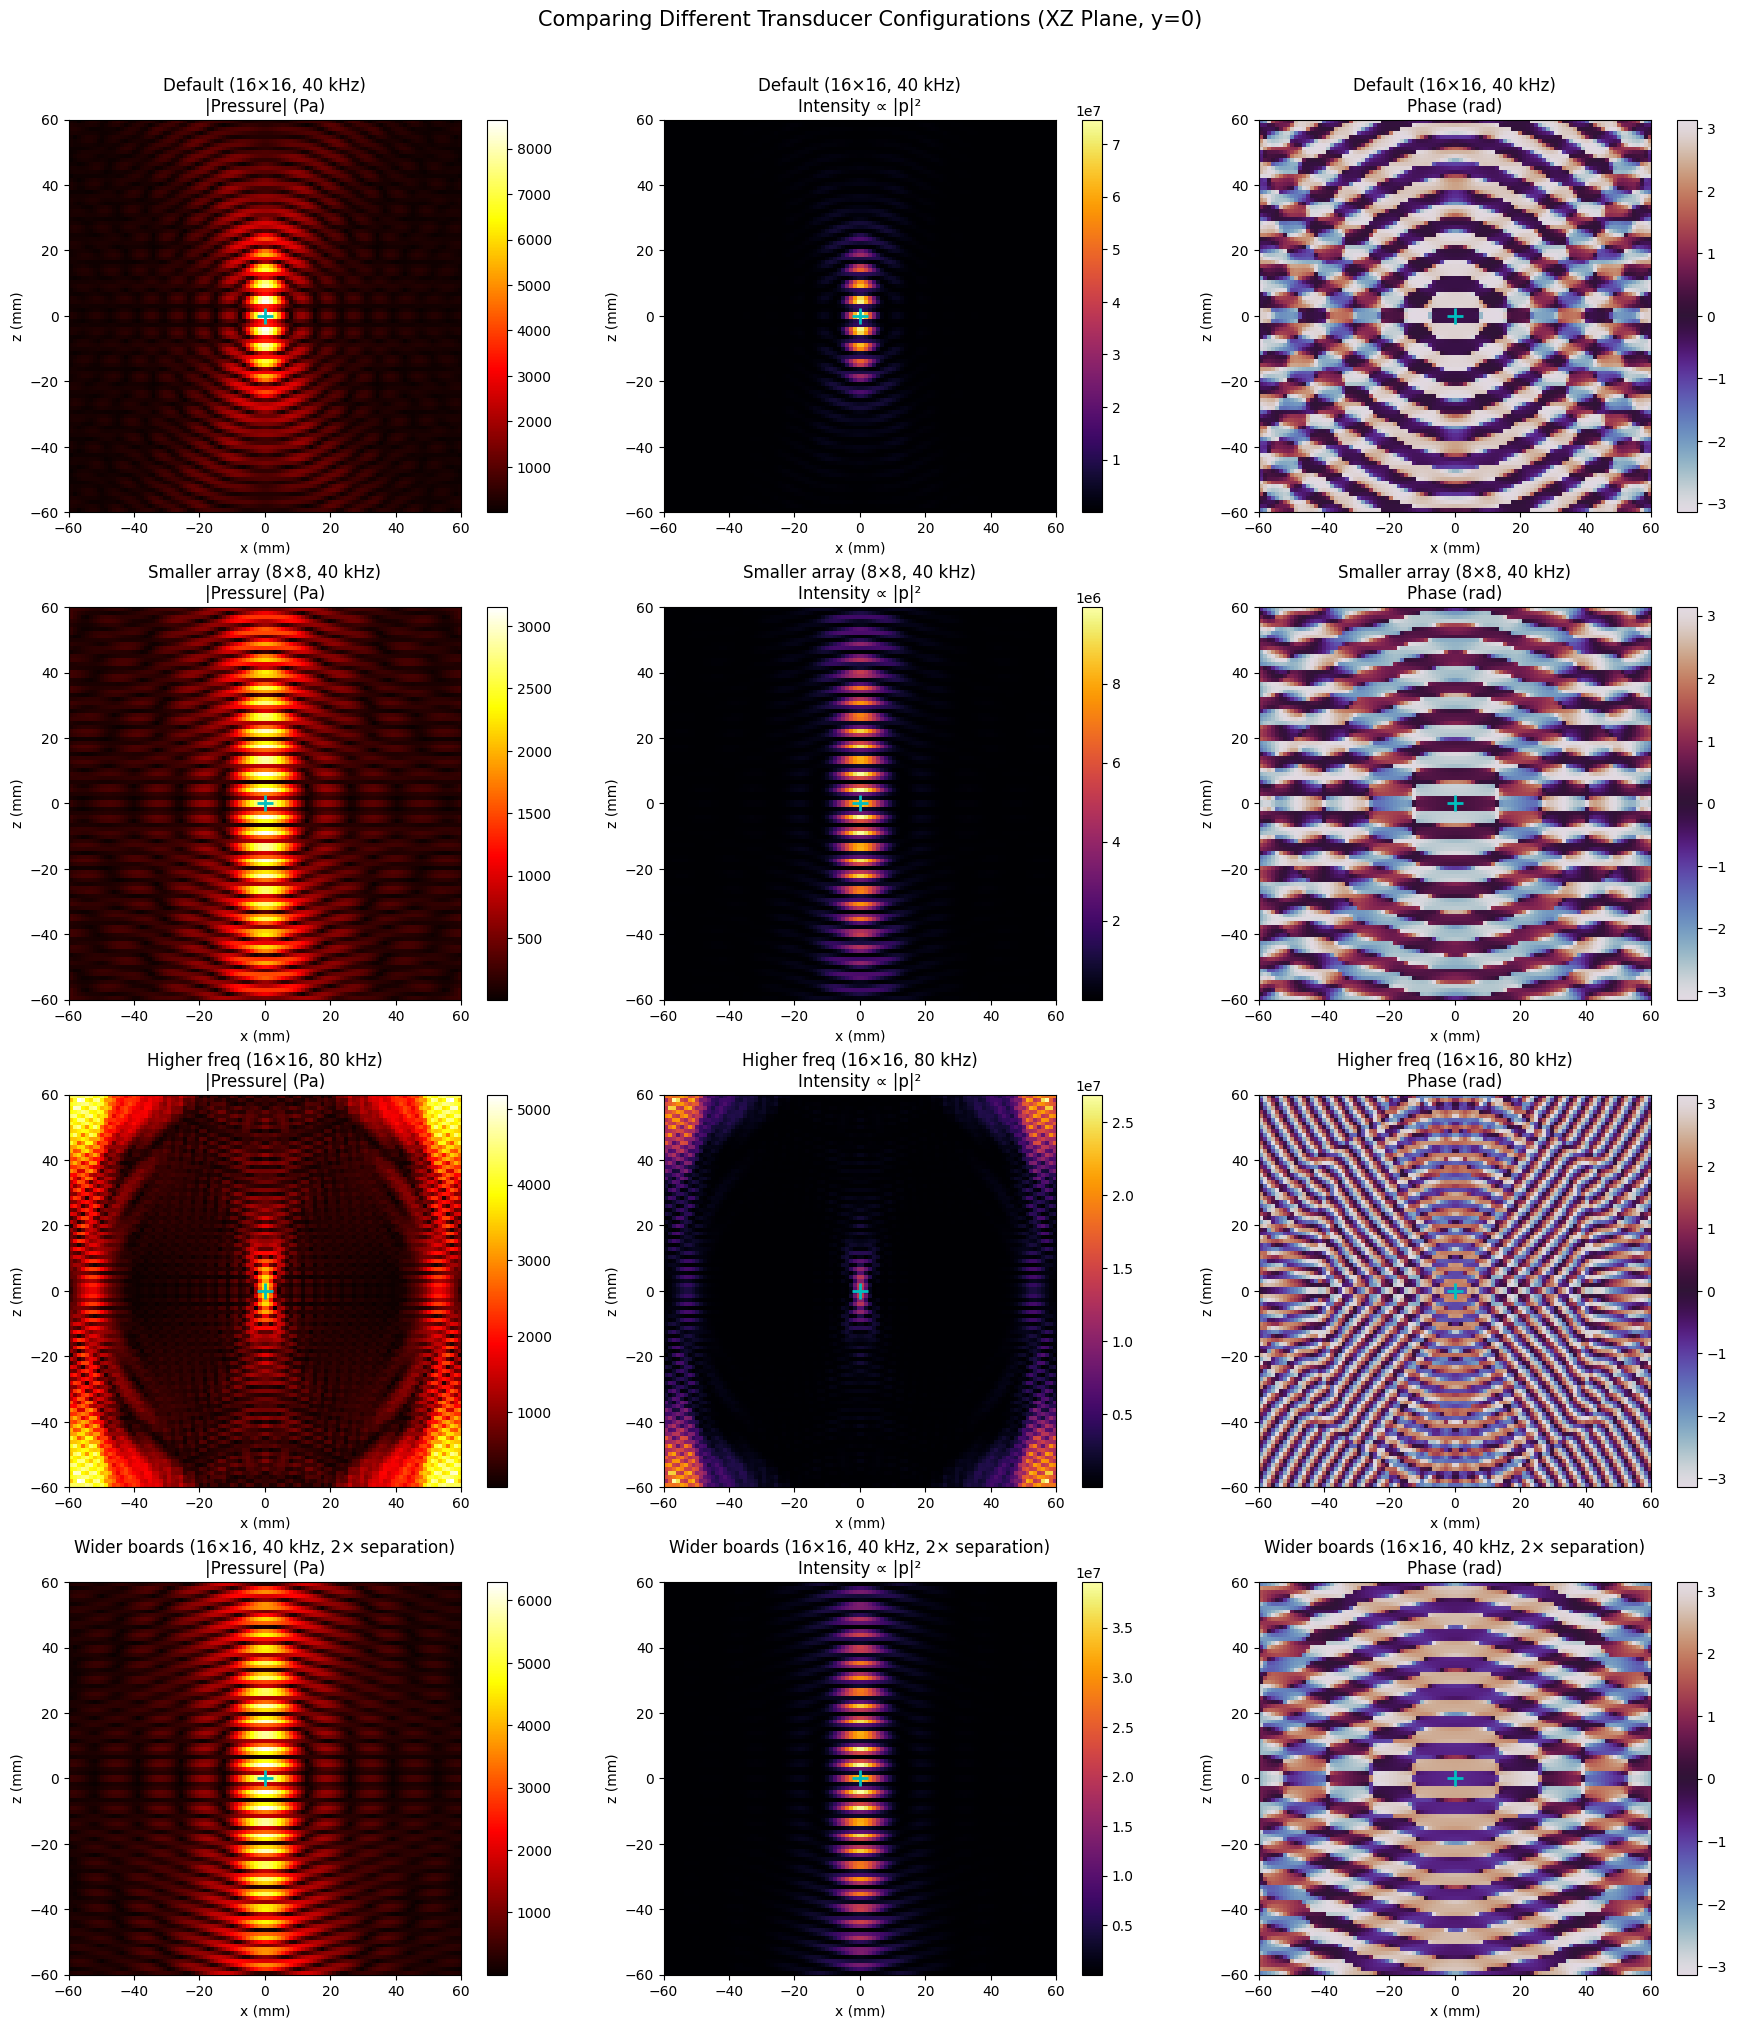

In [44]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from acoustools.Utilities import create_board, propagate
from acoustools.Solvers import wgs

# ======================================================================
# CONFIGURE YOUR EXPERIMENTS HERE — change these values and re-run!
# ======================================================================

experiments = [
    {
        "label": "Default (16×16, 40 kHz)",
        "N": 17,          # 16×16 transducers per board (pass N+1)
        "z": 0.1182,      # board half-separation in metres
        "k": 732.73,      # wavenumber → 40 kHz
        "focus": [0.0, 0.0, 0.0],  # focus point (x, y, z) in metres
    },
    {
        "label": "Smaller array (8×8, 40 kHz)",
        "N": 9,           # 8×8 transducers per board
        "z": 0.1182,
        "k": 732.73,
        "focus": [0.0, 0.0, 0.0],
    },
    {
        "label": "Higher freq (16×16, 80 kHz)",
        "N": 17,
        "z": 0.1182,
        "k": 732.73 * 2,  # double frequency → tighter focus
        "focus": [0.0, 0.0, 0.0],
    },
    {
        "label": "Wider boards (16×16, 40 kHz, 2× separation)",
        "N": 17,
        "z": 0.1182 * 2,  # double the board separation
        "k": 732.73,
        "focus": [0.0, 0.0, 0.0],
    },
]

# ======================================================================
# Plot all experiments (no need to edit below)
# ======================================================================

res = 100
scan_range = 0.06  # ±60mm

fig, axes = plt.subplots(len(experiments), 3, figsize=(18, 5 * len(experiments)))
if len(experiments) == 1:
    axes = axes[np.newaxis, :]

for i, exp in enumerate(experiments):
    # Build custom two-board array
    top = create_board(exp["N"], exp["z"])
    bottom = create_board(exp["N"], -exp["z"])
    board = torch.cat([top, bottom], dim=0)
    n_trans = board.shape[0]

    # Focus point
    fx, fy, fz = exp["focus"]
    point = torch.tensor([[[fx]], [[fy]], [[fz]]])

    # Solve for activations with this board and wavenumber
    act = wgs(point, board=board, k=exp["k"])

    # Create evaluation grid (XZ plane, y=0)
    x_vals = torch.linspace(-scan_range, scan_range, res)
    z_vals = torch.linspace(-scan_range, scan_range, res)
    xx, zz = torch.meshgrid(x_vals, z_vals, indexing='ij')
    eval_pts = torch.stack([
        xx.flatten(), torch.zeros(res * res), zz.flatten()
    ], dim=0).unsqueeze(0)

    # Propagate
    p = propagate(act, eval_pts, board=board, k=exp["k"])[0].reshape(res, res)

    extent = [-scan_range*1000, scan_range*1000, -scan_range*1000, scan_range*1000]

    # Pressure amplitude
    im0 = axes[i, 0].imshow(p.abs().numpy().T, extent=extent, origin='lower', cmap='hot')
    axes[i, 0].set_title(f'{exp["label"]}\n|Pressure| (Pa)')
    axes[i, 0].set_xlabel('x (mm)'); axes[i, 0].set_ylabel('z (mm)')
    axes[i, 0].plot(fx*1000, fz*1000, 'c+', markersize=12, markeredgewidth=2)
    fig.colorbar(im0, ax=axes[i, 0])

    # Intensity
    im1 = axes[i, 1].imshow((p.abs().numpy().T)**2, extent=extent, origin='lower', cmap='inferno')
    axes[i, 1].set_title(f'{exp["label"]}\nIntensity ∝ |p|²')
    axes[i, 1].set_xlabel('x (mm)'); axes[i, 1].set_ylabel('z (mm)')
    axes[i, 1].plot(fx*1000, fz*1000, 'c+', markersize=12, markeredgewidth=2)
    fig.colorbar(im1, ax=axes[i, 1])

    # Phase
    im2 = axes[i, 2].imshow(torch.angle(p).numpy().T, extent=extent, origin='lower', cmap='twilight')
    axes[i, 2].set_title(f'{exp["label"]}\nPhase (rad)')
    axes[i, 2].set_xlabel('x (mm)'); axes[i, 2].set_ylabel('z (mm)')
    axes[i, 2].plot(fx*1000, fz*1000, 'c+', markersize=12, markeredgewidth=2)
    fig.colorbar(im2, ax=axes[i, 2])

    freq_hz = exp["k"] * 343 / (2 * np.pi)
    print(f"[{exp['label']}]  Transducers: {n_trans}, k={exp['k']:.1f}, freq≈{freq_hz:.0f} Hz, "
          f"board z=±{exp['z']*1000:.1f}mm, peak |p|={p.abs().max():.1f} Pa")

plt.suptitle('Comparing Different Transducer Configurations (XZ Plane, y=0)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### Experiment: Moving the Focus Point

What happens when you move the target away from the centre? The focus spot shifts, and the pattern changes. Run the cell below to see 4 different focal positions.

[Centre (0, 0, 0)]  Peak |p| = 8639.2 Pa
[Right 20mm (0.02, 0, 0)]  Peak |p| = 1296.7 Pa
[Up 20mm (0, 0, 0.02)]  Peak |p| = 8639.2 Pa
[Diagonal (0.02, 0, 0.02)]  Peak |p| = 1296.7 Pa


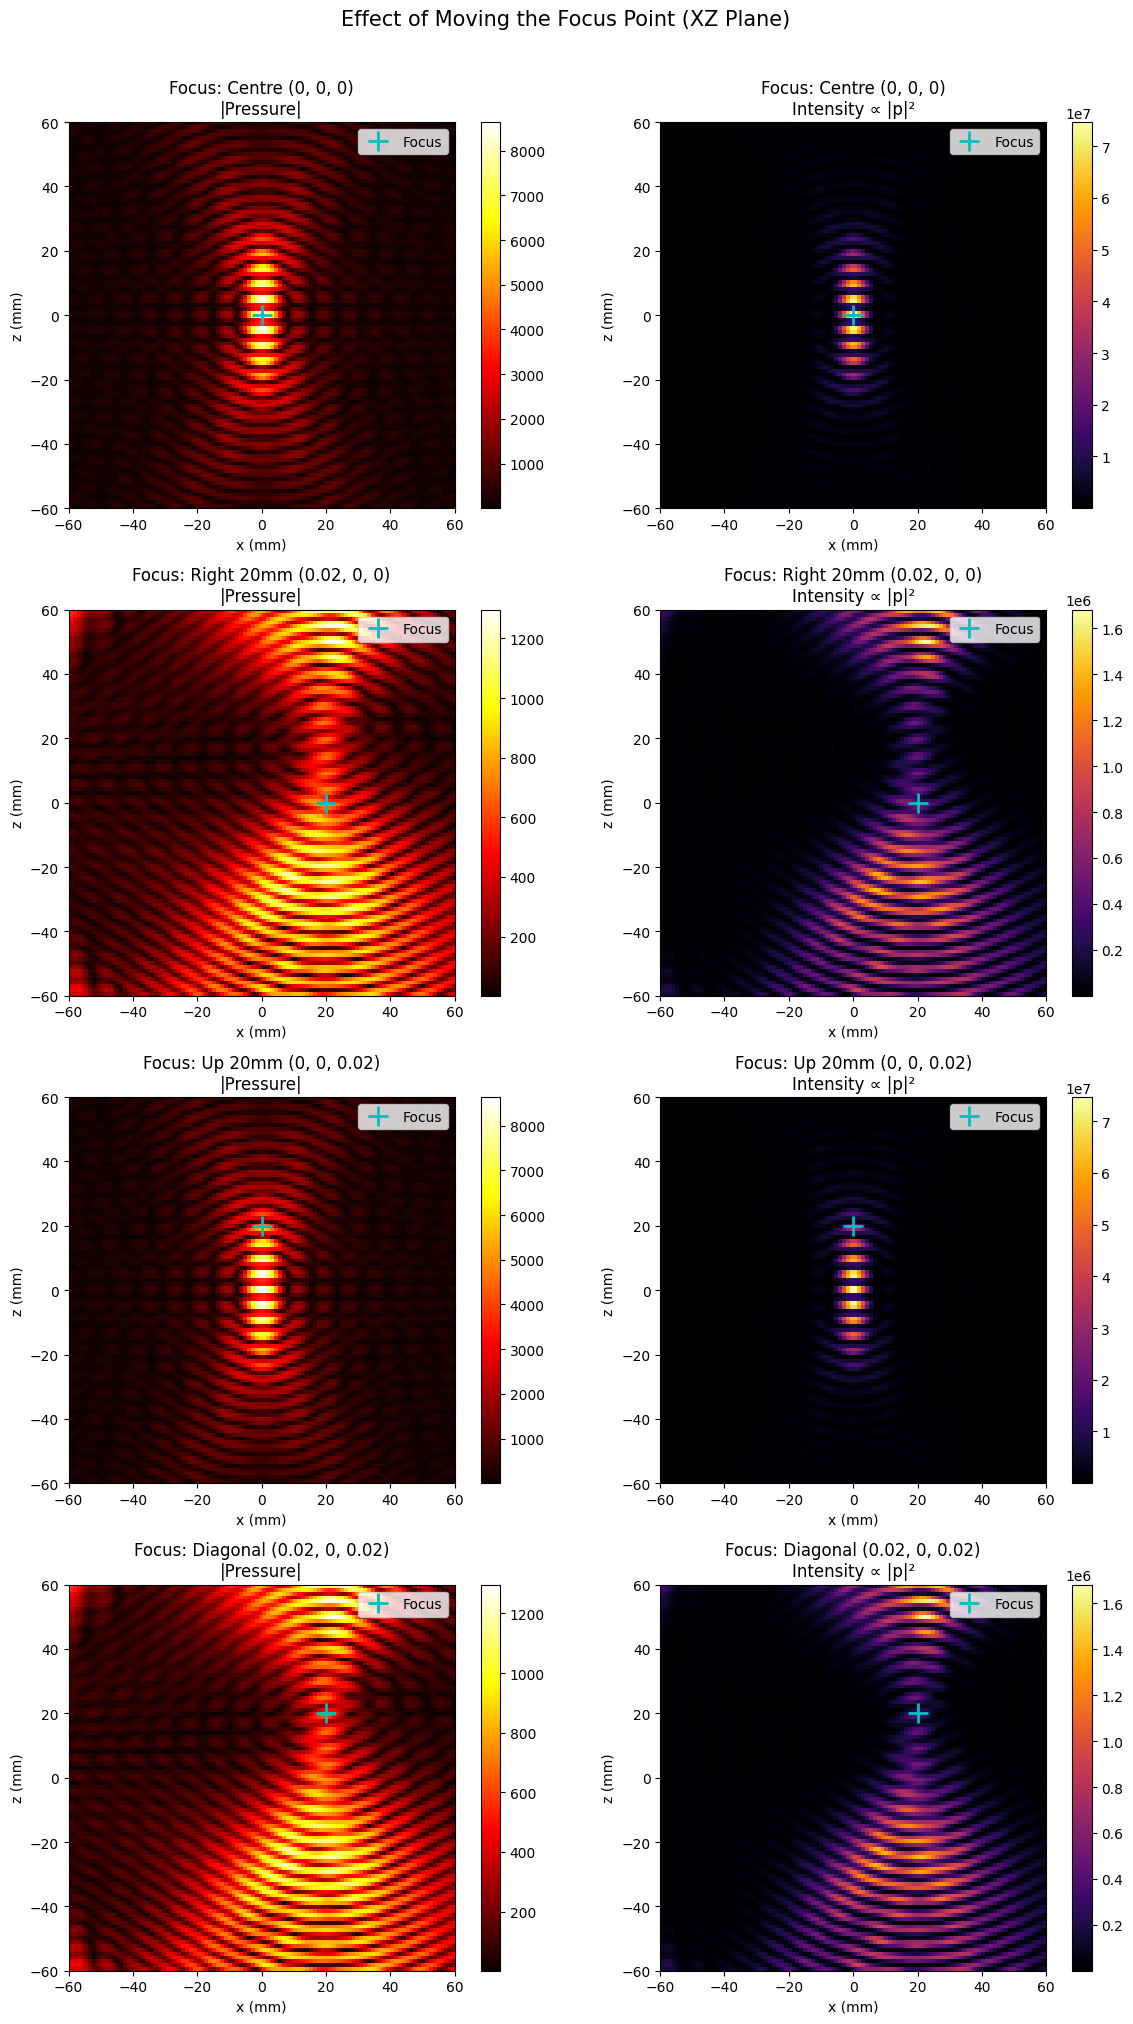

In [45]:
# Compare different focus positions using the default board
from acoustools.Utilities import TRANSDUCERS

focus_positions = [
    {"label": "Centre (0, 0, 0)",       "pos": [0.0,  0.0,  0.0]},
    {"label": "Right 20mm (0.02, 0, 0)","pos": [0.02, 0.0,  0.0]},
    {"label": "Up 20mm (0, 0, 0.02)",   "pos": [0.0,  0.0,  0.02]},
    {"label": "Diagonal (0.02, 0, 0.02)","pos": [0.02, 0.0,  0.02]},
]

res = 100
scan_range = 0.06

fig, axes = plt.subplots(len(focus_positions), 2, figsize=(12, 5 * len(focus_positions)))

for i, fp in enumerate(focus_positions):
    fx, fy, fz = fp["pos"]
    point = torch.tensor([[[fx]], [[fy]], [[fz]]])

    act = wgs(point)  # default board

    # XZ plane
    x_vals = torch.linspace(-scan_range, scan_range, res)
    z_vals = torch.linspace(-scan_range, scan_range, res)
    xx, zz = torch.meshgrid(x_vals, z_vals, indexing='ij')
    eval_pts = torch.stack([
        xx.flatten(), torch.zeros(res * res), zz.flatten()
    ], dim=0).unsqueeze(0)

    p = propagate(act, eval_pts)[0].reshape(res, res)
    extent = [-scan_range*1000, scan_range*1000, -scan_range*1000, scan_range*1000]

    # Pressure
    im0 = axes[i, 0].imshow(p.abs().numpy().T, extent=extent, origin='lower', cmap='hot')
    axes[i, 0].set_title(f'Focus: {fp["label"]}\n|Pressure|')
    axes[i, 0].set_xlabel('x (mm)'); axes[i, 0].set_ylabel('z (mm)')
    axes[i, 0].plot(fx*1000, fz*1000, 'c+', markersize=15, markeredgewidth=2, label='Focus')
    axes[i, 0].legend()
    fig.colorbar(im0, ax=axes[i, 0])

    # Intensity
    im1 = axes[i, 1].imshow((p.abs().numpy().T)**2, extent=extent, origin='lower', cmap='inferno')
    axes[i, 1].set_title(f'Focus: {fp["label"]}\nIntensity ∝ |p|²')
    axes[i, 1].set_xlabel('x (mm)'); axes[i, 1].set_ylabel('z (mm)')
    axes[i, 1].plot(fx*1000, fz*1000, 'c+', markersize=15, markeredgewidth=2, label='Focus')
    axes[i, 1].legend()
    fig.colorbar(im1, ax=axes[i, 1])

    print(f"[{fp['label']}]  Peak |p| = {p.abs().max():.1f} Pa")

plt.suptitle('Effect of Moving the Focus Point (XZ Plane)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### Experiment: Manual Transducer Control

Each transducer gets a **complex number** as its activation:  
- **Amplitude** (how loud) = |activation|  
- **Phase** (timing delay) = angle(activation)

All transducers emit at the **same frequency** — you can only control the amplitude and phase of each one individually. Below we compare:

1. **All in phase** — every transducer has phase=0 (flat wavefront, like a plane wave)
2. **Random phases** — chaotic interference pattern (no focus)
3. **Solver-computed** — WGS finds the optimal phases to focus at (0,0,0)
4. **Only top board active** — bottom board turned off (half the transducers silent)

Total transducers: 512
Top board: transducers 0-255 (z > 0)
Bottom board: transducers 256-511 (z < 0)
[All in phase (φ=0)]  peak |p| = 905.8 Pa,  phases range: 0.00 to 0.00 rad
[Random phases]  peak |p| = 1061.7 Pa,  phases range: -3.14 to 3.14 rad
[WGS solver → focus at origin]  peak |p| = 8639.2 Pa,  phases range: -3.09 to 3.01 rad
[Top board only (bottom off)]  peak |p| = 4689.4 Pa,  phases range: -3.09 to 3.01 rad


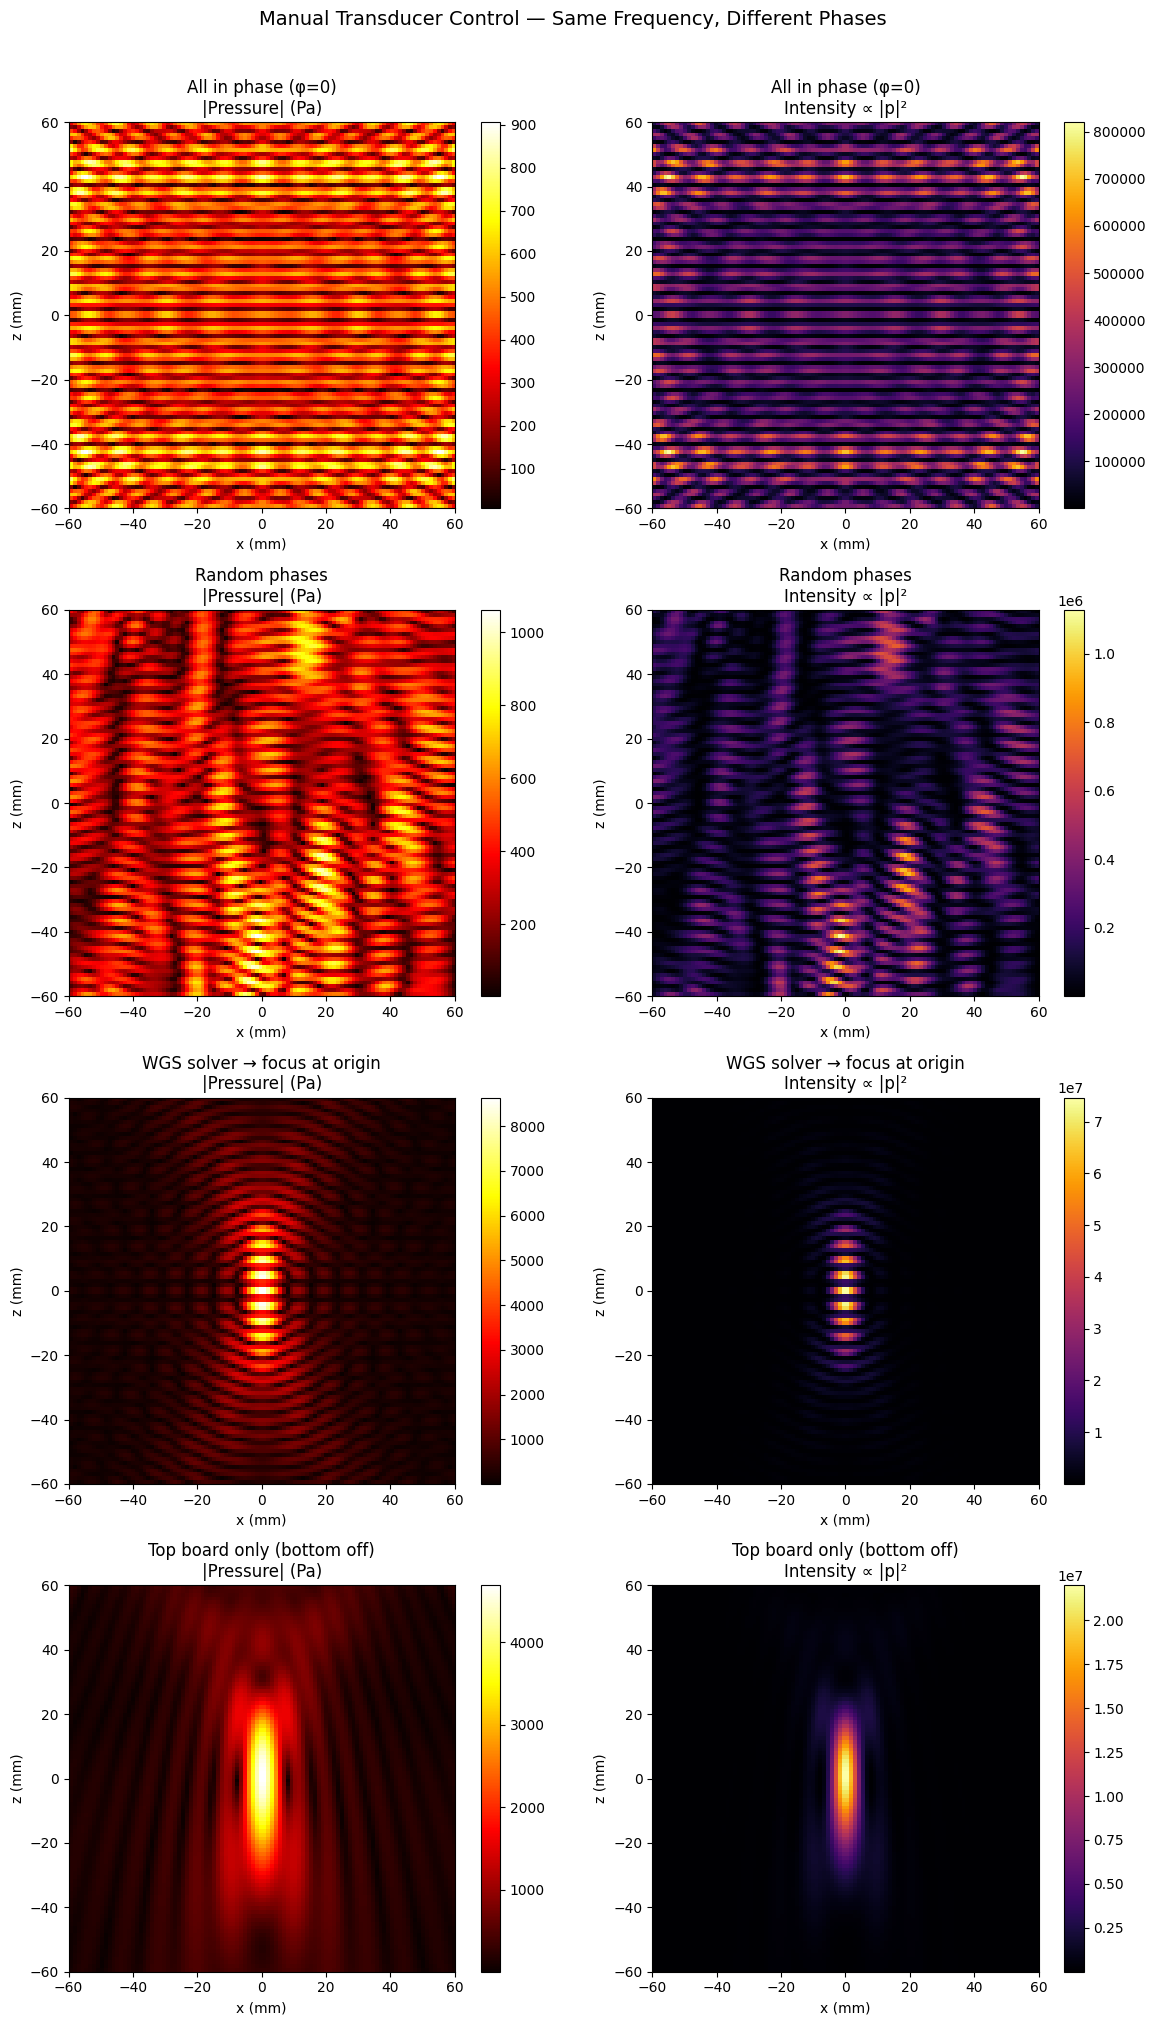

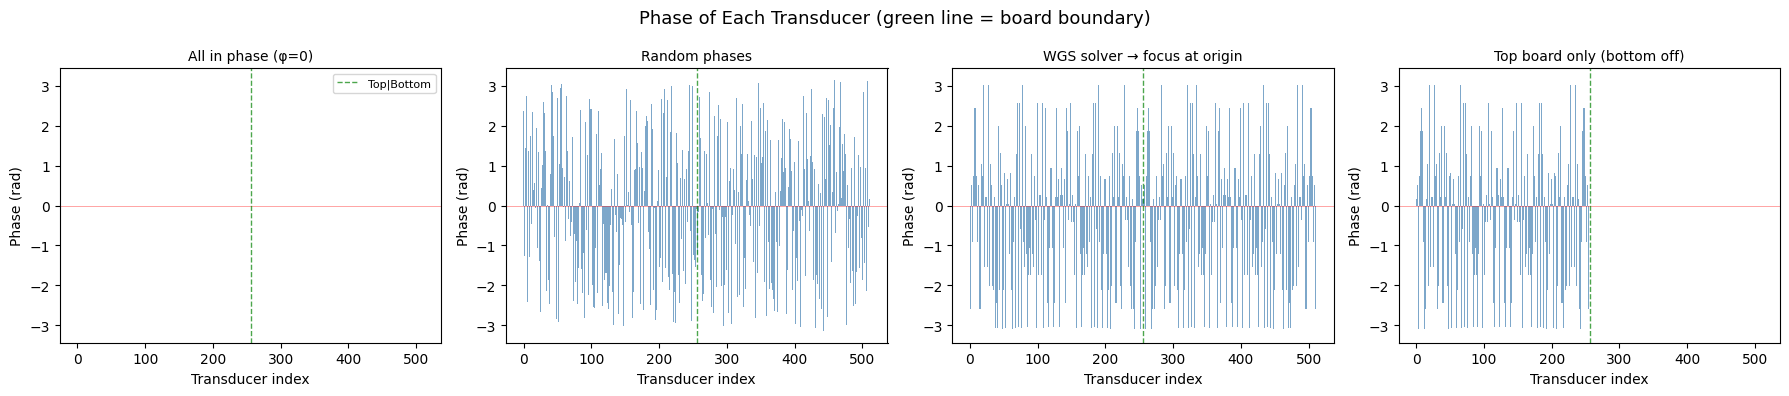

In [46]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from acoustools.Utilities import TRANSDUCERS, propagate
from acoustools.Solvers import wgs

n_transducers = TRANSDUCERS.shape[0]  # 512
print(f"Total transducers: {n_transducers}")
print(f"Top board: transducers 0-255 (z > 0)")
print(f"Bottom board: transducers 256-511 (z < 0)")

# ======================================================================
# BUILD 4 DIFFERENT ACTIVATION PATTERNS MANUALLY
# Each activation is a complex tensor of shape (1, N_transducers, 1)
# ======================================================================

# 1) ALL IN PHASE — every transducer emits with phase=0, amplitude=1
#    This creates a flat wavefront (like a plane wave from each board)
act_flat = torch.ones(1, n_transducers, 1, dtype=torch.complex64)

# 2) RANDOM PHASES — each transducer gets a random phase, amplitude=1
#    This creates chaotic interference — no coherent focus
random_phases = torch.rand(1, n_transducers, 1) * 2 * np.pi
act_random = torch.exp(1j * random_phases).to(torch.complex64)

# 3) SOLVER (WGS) — optimal phases to focus at origin
point = torch.zeros(1, 3, 1)
act_solver = wgs(point)

# 4) TOP BOARD ONLY — silence the bottom 256 transducers
act_top_only = act_solver.clone()
act_top_only[:, 256:, :] = 0  # turn off bottom board

# Labels
configs = [
    ("All in phase (φ=0)", act_flat),
    ("Random phases", act_random),
    ("WGS solver → focus at origin", act_solver),
    ("Top board only (bottom off)", act_top_only),
]

# ======================================================================
# VISUALISE EACH CONFIGURATION
# ======================================================================
res = 100
scan_range = 0.06
x_vals = torch.linspace(-scan_range, scan_range, res)
z_vals = torch.linspace(-scan_range, scan_range, res)
xx, zz = torch.meshgrid(x_vals, z_vals, indexing='ij')
eval_pts = torch.stack([
    xx.flatten(), torch.zeros(res * res), zz.flatten()
], dim=0).unsqueeze(0)

extent = [-60, 60, -60, 60]

fig, axes = plt.subplots(len(configs), 2, figsize=(12, 5 * len(configs)))

for i, (label, act) in enumerate(configs):
    p = propagate(act, eval_pts)[0].reshape(res, res)

    # Pressure amplitude
    im0 = axes[i, 0].imshow(p.abs().numpy().T, extent=extent, origin='lower', cmap='hot')
    axes[i, 0].set_title(f'{label}\n|Pressure| (Pa)', fontsize=12)
    axes[i, 0].set_xlabel('x (mm)'); axes[i, 0].set_ylabel('z (mm)')
    fig.colorbar(im0, ax=axes[i, 0])

    # Intensity
    im1 = axes[i, 1].imshow((p.abs().numpy().T)**2, extent=extent, origin='lower', cmap='inferno')
    axes[i, 1].set_title(f'{label}\nIntensity ∝ |p|²', fontsize=12)
    axes[i, 1].set_xlabel('x (mm)'); axes[i, 1].set_ylabel('z (mm)')
    fig.colorbar(im1, ax=axes[i, 1])

    print(f"[{label}]  peak |p| = {p.abs().max():.1f} Pa,  "
          f"phases range: {torch.angle(act).min():.2f} to {torch.angle(act).max():.2f} rad")

plt.suptitle('Manual Transducer Control — Same Frequency, Different Phases', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ======================================================================
# SHOW WHAT THE ACTIVATIONS LOOK LIKE PER TRANSDUCER
# ======================================================================
fig2, axes2 = plt.subplots(1, 4, figsize=(18, 4))
for i, (label, act) in enumerate(configs):
    phases = torch.angle(act).squeeze().numpy()
    axes2[i].bar(range(n_transducers), phases, width=1.0, color='steelblue', alpha=0.7)
    axes2[i].set_title(label, fontsize=10)
    axes2[i].set_xlabel('Transducer index')
    axes2[i].set_ylabel('Phase (rad)')
    axes2[i].set_ylim(-np.pi - 0.3, np.pi + 0.3)
    axes2[i].axhline(0, color='red', linewidth=0.5, alpha=0.5)
    axes2[i].axvline(256, color='green', linewidth=1, linestyle='--', alpha=0.7, label='Top|Bottom')
    if i == 0:
        axes2[i].legend(fontsize=8)

plt.suptitle('Phase of Each Transducer (green line = board boundary)', fontsize=13)
plt.tight_layout()
plt.show()